In [2]:
import os
import torch
import numpy as np
import pandas as pd
from natsort import natsorted
from torch.utils.data import Dataset, DataLoader as TorchDataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm


def normalize(tensor):
    min_val = tensor.amin(dim=-1, keepdim=True)
    max_val = tensor.amax(dim=-1, keepdim=True)
    return (tensor - min_val) / (max_val - min_val + 1e-8)


class SpectralLoss(nn.Module):
    def __init__(self):
        super(SpectralLoss, self).__init__()

    def forward(self, x, y):
        # Apply FFT along the time dimension (last dim assumed to be time)
        x_fft = torch.fft.rfft(x, dim=-1)
        y_fft = torch.fft.rfft(y, dim=-1)

        # Compare magnitude spectrum
        x_mag = torch.abs(x_fft)
        y_mag = torch.abs(y_fft)

        return F.mse_loss(x_mag, y_mag)

class CombinedLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=1.0):
        super(CombinedLoss, self).__init__()
        self.mse = nn.MSELoss()
        self.spectral = SpectralLoss()
        self.alpha = alpha  # weight for MSE
        self.beta = beta    # weight for spectral

    def forward(self, recon, target):
        mse_loss = self.mse(recon, target)
        spectral_loss = self.spectral(recon, target)
        return self.alpha * mse_loss + self.beta * spectral_loss


class Encoder_1(nn.Module):
    def __init__(self, dropout_rate=0.2):
        super(Encoder_1, self).__init__()

        self.dropout_rate = dropout_rate
        self.conv1 = nn.Conv2d(1, 128, kernel_size=(1, 5), stride=(1,2) ,padding=(0, 0)) 
        self.batchnorm1 = nn.BatchNorm2d(128)  
        self.dropout1 = nn.Dropout(self.dropout_rate)
        self.conv2 = nn.Conv2d(128, 256, kernel_size=(1, 3), stride=(1,1) ,padding=(0, 0))   
        self.batchnorm2 = nn.BatchNorm2d(256)
        self.dropout2 = nn.Dropout(self.dropout_rate)
        self.conv3 = nn.Conv2d(256, 512, kernel_size=(1, 3), stride=(1,2) ,padding=(0, 0))   
        self.batchnorm3 = nn.BatchNorm2d(512)
        self.dropout3 = nn.Dropout(self.dropout_rate)
        self.conv4 = nn.Conv2d(512, 1, kernel_size=(1, 3), stride=(1,1) ,padding=(0, 0))   
        self.leaky_relu = nn.LeakyReLU(0.1, inplace=True)

    def forward(self, x):
        # print(x.shape)
        x = F.relu(self.conv1(x))
        x = self.batchnorm1(x)
        x = self.dropout1(x)
        # print(x.shape)
        x = self.leaky_relu(self.conv2(x))
        x = self.batchnorm2(x)
        x = self.dropout2(x)
        # print(x.shape)
        x = F.elu(self.conv3(x)); 
        x = self.batchnorm3(x)
        x = self.dropout3(x)
        # print(x.shape)
        x = self.conv4(x); 
        # print(x.shape)
        return x 

class Decoder_1(nn.Module):
    def __init__(self, dropout_rate=0.2):
        self.dropout_rate = dropout_rate

        super(Decoder_1, self).__init__()
        self.deconv1 = nn.ConvTranspose2d(1, 512, kernel_size=(1, 3), stride=(1, 1))   
        self.deconv1_bn = nn.BatchNorm2d(512)
        self.deconv1_dp = nn.Dropout(self.dropout_rate)            
        self.deconv2 = nn.ConvTranspose2d(512, 256, kernel_size=(1, 3), stride=(1, 2), output_padding=(0, 1))  # W: 34 → 69
        self.deconv2_bn = nn.BatchNorm2d(256)
        self.deconv2_dp = nn.Dropout(self.dropout_rate)
        self.deconv3 = nn.ConvTranspose2d(256, 128, kernel_size=(1, 3), stride=(1, 1), output_padding=(0, 0))   # W: 69 → 141
        self.deconv3_bn = nn.BatchNorm2d(128)
        self.deconv3_dp = nn.Dropout(self.dropout_rate)
        self.deconv4 = nn.ConvTranspose2d(128, 1, kernel_size=(1, 5), stride=(1, 2), output_padding=(0, 1))    # W: 141 → 300

    def forward(self, x):
        x = F.relu(self.deconv1(x))         
        x = self.deconv1_bn(x)
        x = self.deconv1_dp(x)
        # print("deconv1:", x.shape)
        x = F.softplus(self.deconv2(x))     # (B, 64, 1, 69)
        x = self.deconv2_bn(x)
        x = self.deconv2_dp(x)
        # print("deconv2:", x.shape)
        x = F.elu(self.deconv3(x))          # (B, 32, 1, 141)
        x = self.deconv3_bn(x)
        x = self.deconv3_dp(x)
        # print("deconv3:", x.shape)
        # x = F.tanh(self.deconv4(x))         # (B, 5, 1, 300)
        x = (self.deconv4(x))         # (B, 5, 1, 300)
        # print("deconv4:", x.shape)
        return x

        
class Autoencoder_type1(nn.Module):
    def __init__(self, dropout_rate=0.2):
        super(Autoencoder_type1, self).__init__()
        self.dropout_rate = dropout_rate
        self.encoder = Encoder_1(self.dropout_rate)
        self.decoder = Decoder_1(self.dropout_rate)

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent


if __name__ == "__main__":
    x = torch.randn(133, 1, 8, 400)# Example input (B=1, C=1, H=1, W=200)
    model1 = Autoencoder_type1(dropout_rate=0.2)
    reconstructed, latent = model1(x)
    print("Input shape:", x.shape)
    print("Reconstructed shape:", reconstructed.shape) 
    print("Latent shape:", latent.shape) 

Input shape: torch.Size([133, 1, 8, 400])
Reconstructed shape: torch.Size([133, 1, 8, 400])
Latent shape: torch.Size([133, 1, 8, 95])


In [25]:
from models import Simple1DCNN
from scipy.stats import entropy

# AE model v2 was trained on data augmented with zeros
rock_ae_weights = torch.load("param_autoencoder_rock_v2.pth", map_location=torch.device('mps'))
rock_ae = Autoencoder_type1(dropout_rate=0.2)
rock_ae.load_state_dict(rock_ae_weights)
rock_ae.eval()

# rock_classifier_weights = torch.load("param_classifier_rock_v2.pth", map_location=torch.device('mps'))
# rock_classifier = Simple1DCNN(num_sensors=8, num_classes=2)
# rock_classifier.load_state_dict(rock_classifier_weights)
# rock_classifier.eval()
num_sensors = 8

x = torch.randn(133, 1, 8, 400)

# [8, 133] entropy values for 
#    8 sensors
#    133 samples
entropy_values = torch.zeros(num_sensors, x.size(0), device=x.device)

with torch.no_grad():
    for ablated_sensor in range(num_sensors):
        print(f"Ablating sensor {ablated_sensor + 1}/{num_sensors}")

        _, latent = rock_ae(x)
        
        latent = latent.squeeze(1) # Shape: [133, 8*95]
        
        # Calculate entropy for each sample
        entropy_values_ablated_sensor = torch.zeros(latent.size(0), device=latent.device)
        for i in range(latent.size(0)):
            entropy_values_per_dim_1 = torch.zeros(num_sensors, device=latent.device)
            for j in range(num_sensors):
                hist = torch.histc(latent[i][j], bins=50, min=latent[i][j].min(), max=latent[i][j].max())
                prob_dist = hist / hist.sum()
                prob_dist = prob_dist[prob_dist > 0]
                entropy_values_per_dim_1 = -torch.sum(prob_dist * torch.log2(prob_dist))
            entropy_values_ablated_sensor[i] = torch.mean(entropy_values_per_dim_1)

        entropy_values[ablated_sensor] = entropy_values_ablated_sensor

entropy_values = entropy_values.detach().cpu().numpy()
entropy_values.shape

Ablating sensor 1/8
Ablating sensor 2/8
Ablating sensor 3/8
Ablating sensor 4/8
Ablating sensor 5/8
Ablating sensor 6/8
Ablating sensor 7/8
Ablating sensor 8/8


(8, 133)

Sensor 1: Mean = 5.0099, Variance = 0.0156
Sensor 2: Mean = 5.0099, Variance = 0.0156
Sensor 3: Mean = 5.0099, Variance = 0.0156
Sensor 4: Mean = 5.0099, Variance = 0.0156
Sensor 5: Mean = 5.0099, Variance = 0.0156
Sensor 6: Mean = 5.0099, Variance = 0.0156
Sensor 7: Mean = 5.0099, Variance = 0.0156
Sensor 8: Mean = 5.0099, Variance = 0.0156


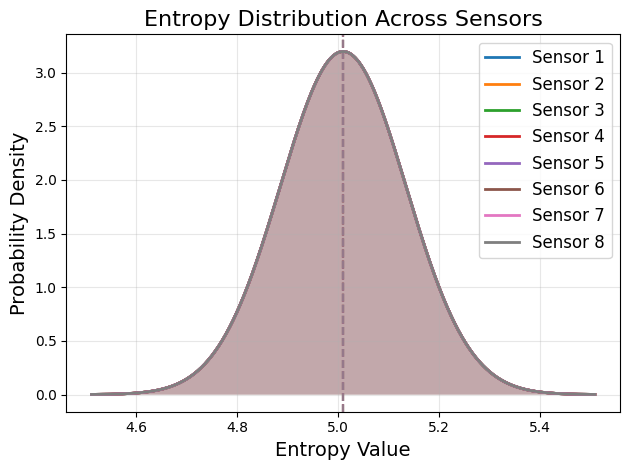

In [33]:
import matplotlib.pyplot as plt

mean_sensors = np.mean(entropy_values, axis=1)
cov_sensors = np.cov(entropy_values, rowvar=True)

# Print mean and variance for each sensor
for i in range(num_sensors):
    print(f"Sensor {i + 1}: Mean = {mean_sensors[i]:.4f}, Variance = {cov_sensors[i, i]:.4f}")

# For each sensor, create a density plot
for i in range(num_sensors):
    mu = mean_sensors[i]
    sigma = np.sqrt(cov_sensors[i, i])
    
    # Create a range of x values for the normal distribution
    x_range = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
    
    # Calculate normal distribution PDF values
    pdf = 1/(np.sqrt(2*np.pi*cov_sensors[i, i])) * np.exp(-(x_range - mean_sensors[i])**2/(2*cov_sensors[i, i]))
    
    # Plot the normal distribution for this sensor
    plt.plot(x_range, pdf, linewidth=2, label=f'Sensor {i + 1}')
    plt.fill_between(x_range, pdf, alpha=0.1)
    
    # Mark the mean with vertical lines
    plt.axvline(mu, color=plt.gca().lines[-1].get_color(), linestyle='--', alpha=0.7)

# Add labels and legend
plt.title("Entropy Distribution Across Sensors", fontsize=16)
plt.xlabel("Entropy Value", fontsize=14)
plt.ylabel("Probability Density", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()